In [1]:
import numpy as np
from sklearn.cluster import KMeans

c:\Python312\Lib\site-packages\sklearn\utils\__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy.sparse import issparse


In [4]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=600, centers=7, n_features=2, random_state=42)

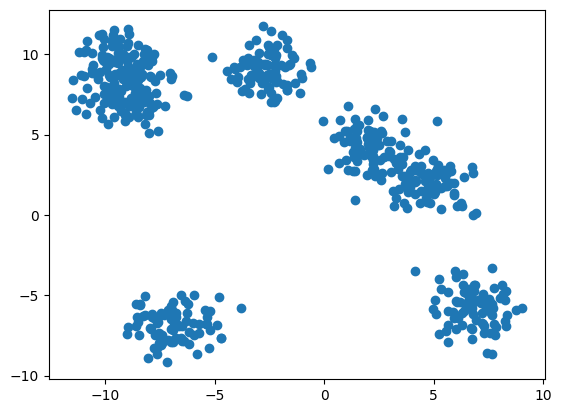

In [5]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])

In [6]:
#tree structure

class HKMnode:
    def __init__(self, centroids=None, children=None, leaf=True, points=None):
        self.centroids = centroids
        self.children = children or []
        self.points = points
        self.leaf = leaf

In [7]:
#indexing

def hierarchicalIndexing(data, branching_factor, level, max_level, min_points):
    if data.shape[0] < min_points or level == max_level:
        leaf = HKMnode(points = data, leaf=True)
        return leaf
    
    kmeans = KMeans(n_clusters=branching_factor, random_state=42).fit(data)

    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_
    
    node = HKMnode(centroids=centroids, leaf=False)

    for i in range(branching_factor):
        points_in_cluster = data[labels == i]
        child = hierarchicalIndexing(
            points_in_cluster,
            branching_factor,
            level + 1,
            max_level,
            min_points
        )
        node.children.append(child)
    
    return node


    

In [8]:
root = hierarchicalIndexing(X, 3, 0, 5, 3)

In [9]:
def validate_hkm_tree(node, level=0):
    indent = "  " * level

    # Leaf node checks
    if node.leaf:
        if node.points is None:
            print(f"{indent}❌ Leaf at level {level} has no points")
            return False
        print(f"{indent}✔ Leaf at level {level} with {node.points.shape[0]} points")
        return True

    # Internal node checks
    if node.centroids is None:
        print(f"{indent}❌ Internal node at level {level} has no centroids")
        return False

    print(f"{indent}✔ Internal node at level {level} with {len(node.centroids)} centroids")

    # Check children count
    if len(node.children) != len(node.centroids):
        print(f"{indent}❌ Children count ({len(node.children)}) "
              f"does not match centroid count ({len(node.centroids)})")
        return False

    # Recurse into children
    ok = True
    for child in node.children:
        ok = validate_hkm_tree(child, level + 1) and ok

    return ok


In [10]:
import numpy as np

def collect_leaf_points(node):
    if node.leaf:
        return node.points
    pts = []
    for child in node.children:
        pts.append(collect_leaf_points(child))
    return np.vstack(pts)


In [11]:
leaf_points = collect_leaf_points(root)

print("Original:", X.shape[0])
print("Collected:", leaf_points.shape[0])
print("Match:", X.shape[0] == leaf_points.shape[0])


Original: 600
Collected: 600
Match: True


In [12]:
validate_hkm_tree(root)


✔ Internal node at level 0 with 3 centroids
  ✔ Internal node at level 1 with 3 centroids
    ✔ Internal node at level 2 with 3 centroids
      ✔ Internal node at level 3 with 3 centroids
        ✔ Internal node at level 4 with 3 centroids
          ✔ Leaf at level 5 with 7 points
          ✔ Leaf at level 5 with 3 points
          ✔ Leaf at level 5 with 3 points
        ✔ Internal node at level 4 with 3 centroids
          ✔ Leaf at level 5 with 2 points
          ✔ Leaf at level 5 with 1 points
          ✔ Leaf at level 5 with 3 points
        ✔ Internal node at level 4 with 3 centroids
          ✔ Leaf at level 5 with 2 points
          ✔ Leaf at level 5 with 4 points
          ✔ Leaf at level 5 with 4 points
      ✔ Internal node at level 3 with 3 centroids
        ✔ Internal node at level 4 with 3 centroids
          ✔ Leaf at level 5 with 4 points
          ✔ Leaf at level 5 with 3 points
          ✔ Leaf at level 5 with 4 points
        ✔ Internal node at level 4 with 3 centroid

True

In [13]:
# Searching
# class HKMnode:
#     def __init__(self, centroids=None, children=None, leaf=True, points=None):
#         self.centroids = centroids
#         self.children = children or []
#         self.points = points
#         self.leaf = leaf
def find_nearest_neighbor(node, point):

    norm_sq_point = point @ point
    if(node.leaf == True):
        # go through the points, find the closest one
        distances = []
        for i in range(node.points.shape[0]):
            neighbor = node.points[i]
            neighbor_sq = neighbor @ neighbor
            dist = norm_sq_point + neighbor_sq - 2 * (point @ neighbor)
            distances.append(dist)
        
        idx = distances.index(min(distances))
        return node.points[idx]
    
    #go through the centroids and pass the closes to the find_cluster
    distance_to_centroids = []
    for i in range(node.centroids.shape[0]):
        centroid = node.centroids[i]
        centroid_sq = centroid @ centroid
        dist = norm_sq_point + centroid_sq - 2 * (point @ centroid)
        distance_to_centroids.append(dist)
    
    idx = distance_to_centroids.index(min(distance_to_centroids))
    closest_cluster = node.children[idx]

    return find_nearest_neighbor(closest_cluster, point)
    
    
    

In [53]:
root2 = hierarchicalIndexing(X, 1, 0, 1, 1)

In [76]:
query = np.array([0, -3])

import time

t1 = time.perf_counter()
res = find_nearest_neighbor(root, query)
t1 = time.perf_counter() - t1

t2 = time.perf_counter()
res_fs = find_nearest_neighbor(root2, query)
t2 = time.perf_counter() - t2

print("Time to do HKM: %.4fms \nTime to do full scan: %.4fms" %(t1 * 1000, t2 * 1000))

Time to do HKM: 0.3329ms 
Time to do full scan: 3.1620ms


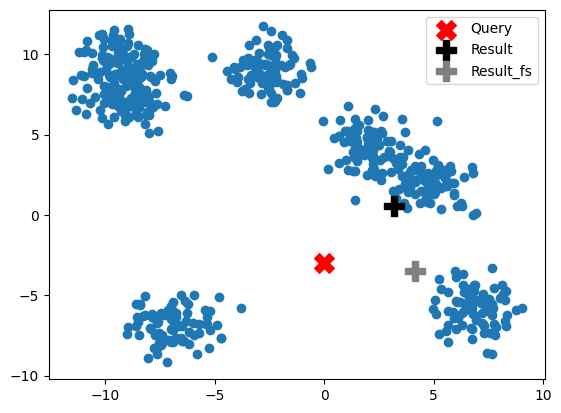

In [75]:
#Full scan -> bf1
plt.scatter(X[:, 0], X[:, 1])
plt.scatter(query[0], query[1], color='red', marker='X', s=200, label='Query')
plt.scatter(res[0], res[1], color='black', marker='P', s=200, label='Result')
plt.scatter(res_fs[0], res_fs[1], color='grey', marker='P', s=200, label='Result_fs')
plt.legend()
plt.show()